In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/IIT/level 05/ML/Coursework/w2119725/regression_data_set.csv')
data.head()

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
0,40.0,182004,3,3,1,35000,8.00,0.19,0,11,35000
1,40.0,90000,0,3,2,35000,12.42,0.39,0,14,35000
2,40.0,131004,0,9,5,30000,7.90,0.23,0,13,30000
3,40.0,150000,0,9,0,25000,11.89,0.17,0,11,25000
4,40.0,132000,0,3,2,25000,16.82,0.22,0,17,25000


Define X and Y

In [ ]:
# define x and y for the regression
x = data.drop('max_allowed_loan', axis=1)
y = data['max_allowed_loan']

In [ ]:
print("Regression input features: ", list(x.columns))
print("Regression data x shape: ", x.shape)
print("Regression data y shape: ", y.shape)

Regression input features:  ['age', 'income', 'home_ownership', 'employment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Regression data x shape:  (50292, 10)
Regression data y shape:  (50292,)


Train-Test split

In [ ]:
# Train and Test sets split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=10
)

In [ ]:
print("x train instances: ", x_train.shape)
print("x test instances: ", x_test.shape)

x train instances:  (35204, 10)
x test instances:  (15088, 10)


DT 1

In [ ]:
regressor = DecisionTreeRegressor()
regressor.fit(x_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = regressor.predict(x_test)

In [ ]:
print("Full Regressor Decision Tree Levels: ", regressor.tree_.max_depth)

Full Regressor Decision Tree Levels:  25


In [ ]:
print('Regression Metrics:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2:', metrics.r2_score(y_test, y_pred))

Regression Metrics:
Mean Absolute Error: 1411.066808059385
Mean Squared Error: 121741609.41635737
Root Mean Squared Error: 11033.658025168143
R2: 0.9701707542412535


In [ ]:
# Unpruned_Tree_figure = plt.figure(figsize=(200, 200))
# DT_Graph = tree.plot_tree(regressor, feature_names=list(x_train.columns), filled=True)
# Unpruned_Tree_figure.savefig("DT1_fully_grown_regression_tree.svg")

DT 2

In [ ]:
pruned_regressor = DecisionTreeRegressor(max_depth=4)
pruned_regressor.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=4)

In [ ]:
y_pred_pruned = pruned_regressor.predict(x_test)

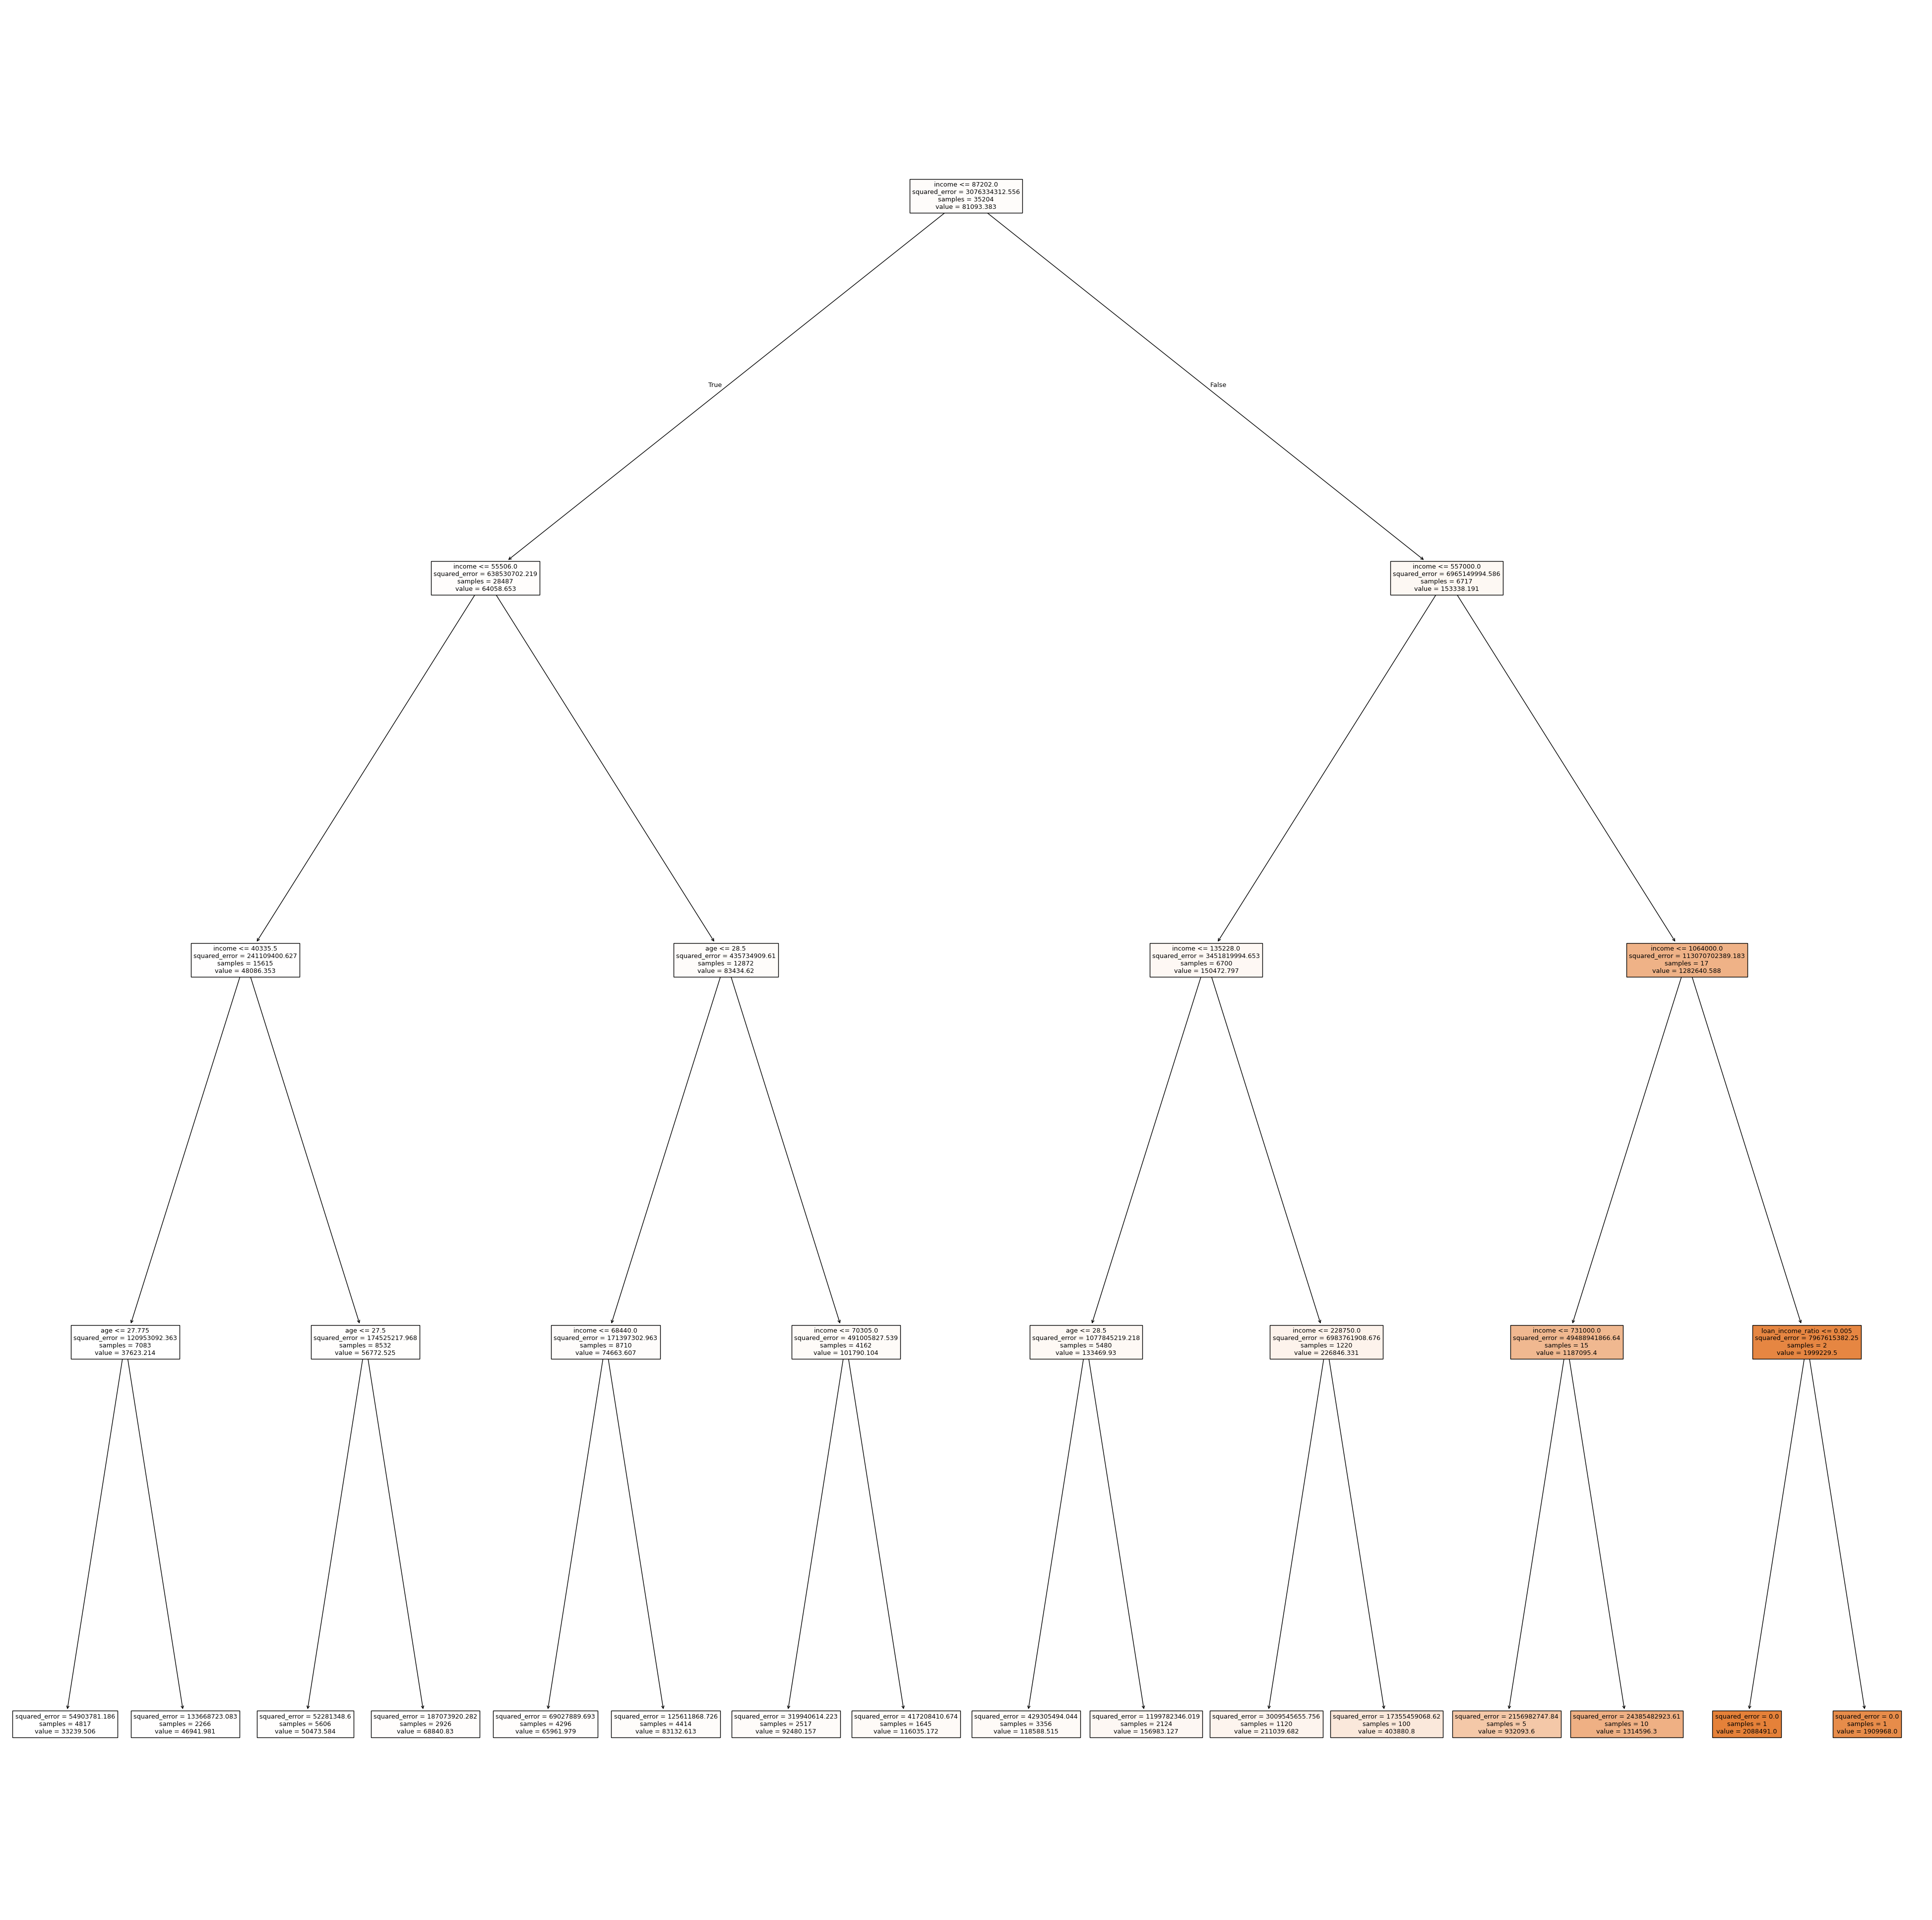

In [ ]:
pruned_Tree_figure = plt.figure(figsize=(50, 50))
pruned_Tree_model_Graph = tree.plot_tree(pruned_regressor, feature_names=list(x_train.columns), filled=True)
pruned_Tree_figure.savefig("DT2_pruned_regression_tree.png")

In [ ]:
print(' Regression Metrics (Pruned to 4 Levels)')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_pruned))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_pruned))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_pruned)))
print('R2:', metrics.r2_score(y_test, y_pred_pruned))

 Regression Metrics (Pruned to 4 Levels)
Mean Absolute Error: 11751.038586266915
Mean Squared Error: 489857202.9524475
Root Mean Squared Error: 22132.71792962734
R2: 0.8799747188852475


Predict for client 60256

In [ ]:
client_60256 = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'home_ownership': 3,          # RENT = 3
    'employment_length': 15,
    'loan_intent': 3,             # MEDICAL = 3
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'payment_default_on_file': 0, # No = 0
    'credit_history_length': 35
}])

print("Client 60256 feature values (UNSCALED):")
print(client_60256.T)

Client 60256 feature values (UNSCALED):
                               0
age                         56.0
income                   57000.0
home_ownership               3.0
employment_length           15.0
loan_intent                  3.0
loan_amount              25700.0
loan_interest_rate          23.0
loan_income_ratio            0.1
payment_default_on_file      0.0
credit_history_length       35.0


In [ ]:
# predicted_max_loan = regressor.predict(client_60256)
# print('\n--- Prediction for Client 60256 ---')
# print('Predicted Maximum Loan Amount: £', round(predicted_max_loan[0], 2))

# predict using DT 1
predicted_max_loan_dt1 = regressor.predict(client_60256)
print('--- Prediction for Client 60256 using DT-1 (Fully Grown) ---')
print('Predicted Maximum Loan Amount: £', round(predicted_max_loan_dt1[0], 2))

# Also predict using DT 2 for comparison
predicted_max_loan_dt2 = pruned_regressor.predict(client_60256)
print()
print('--- Prediction for Client 60256 using DT-2 (Pruned to 4 levels) ---')
print('Predicted Maximum Loan Amount: £', round(predicted_max_loan_dt2[0], 2))

--- Prediction for Client 60256 using DT-1 (Fully Grown) ---
Predicted Maximum Loan Amount: £ 87430.0

--- Prediction for Client 60256 using DT-2 (Pruned to 4 levels) ---
Predicted Maximum Loan Amount: £ 92480.16


Ensemble Classifier

In [ ]:
classi_data = pd.read_csv('/content/drive/MyDrive/IIT/level 05/ML/Coursework/w2119725/classification_data_set.csv')
classi_data.head()

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
1,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0
2,40.0,131004,0,9,5,30000,7.90,0.23,0,13,0
3,40.0,150000,0,9,0,25000,11.89,0.17,0,11,0
4,40.0,132000,0,3,2,25000,16.82,0.22,0,17,0


In [ ]:
x_classi = classi_data.drop(columns=['loan_approval_status'])
y_classi = classi_data['loan_approval_status']

In [ ]:
x_classi_train, x_classi_test , y_classi_train, y_classi_test = train_test_split(
    x_classi, y_classi, test_size=0.3, random_state=42, stratify=y_classi
)

print("Classification train shape: ", x_classi_train.shape)
print("Classification test shape: ", x_classi_test.shape)

Classification train shape:  (37123, 10)
Classification test shape:  (15910, 10)


In [ ]:
nb = GaussianNB()
nb = nb.fit(x_classi_train, y_classi_train)
y_nb_pred = nb.predict(x_classi_test)

print("Classification report for NB")
print(classification_report(y_classi_test, y_nb_pred))

Classification report for NB
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     13561
           1       0.69      0.36      0.47      2349

    accuracy                           0.88     15910
   macro avg       0.80      0.66      0.70     15910
weighted avg       0.87      0.88      0.87     15910



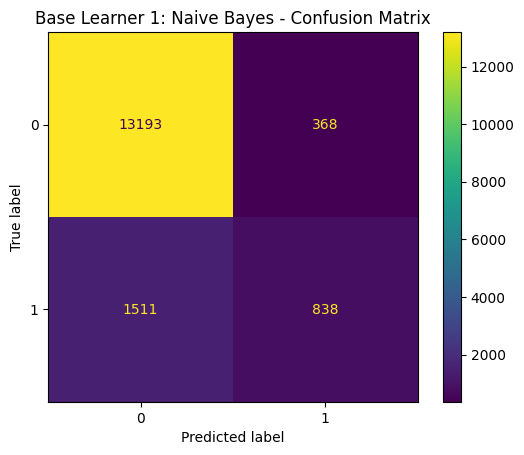

In [ ]:
nb_cm = confusion_matrix(y_classi_test, y_nb_pred, labels=nb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=nb_cm, display_labels=nb.classes_)
disp.plot()
plt.title('Base Learner 1: Naive Bayes - Confusion Matrix')
plt.show()

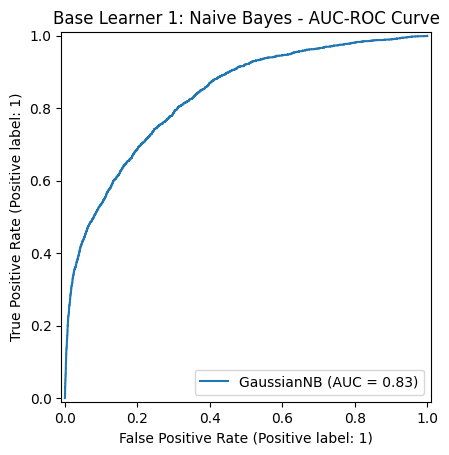

In [ ]:
nb_roc = RocCurveDisplay.from_estimator(nb, x_classi_test, y_classi_test)
plt.title('Base Learner 1: Naive Bayes - AUC-ROC Curve')
plt.show()

Base Learner 2

Classification report for KNN
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     13561
           1       0.66      0.49      0.56      2349

    accuracy                           0.89     15910
   macro avg       0.79      0.72      0.75     15910
weighted avg       0.88      0.89      0.88     15910



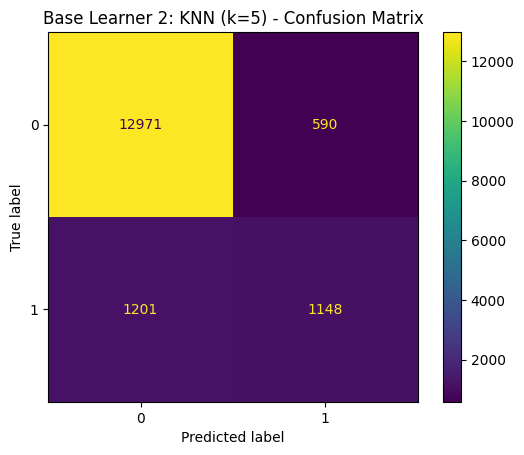

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn = knn.fit(x_classi_train, y_classi_train)
y_knn_pred = knn.predict(x_classi_test)

print("Classification report for KNN")
print(classification_report(y_classi_test, y_knn_pred))

knn_cm = confusion_matrix(y_classi_test, y_knn_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=knn_cm, display_labels=knn.classes_)
disp.plot()
plt.title('Base Learner 2: KNN (k=5) - Confusion Matrix')
plt.show()

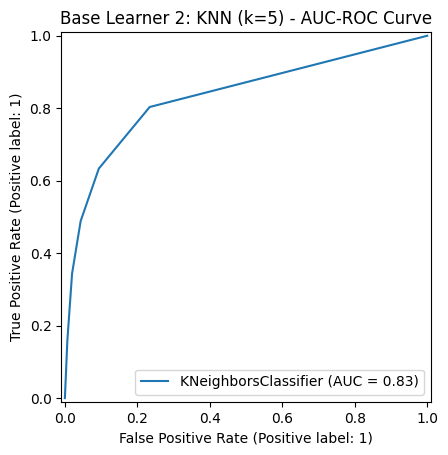

In [ ]:
knn_roc = RocCurveDisplay.from_estimator(knn, x_classi_test, y_classi_test)
plt.title('Base Learner 2: KNN (k=5) - AUC-ROC Curve')
plt.show()

Voting for the Ensemble Classifier

In [ ]:
# Create list of the two chosen base learner models
base_learners = [('NB', nb), ('KNN', knn)]

# Create soft voting classifier (probability-based — required by report Task 5f)
ensemble_learner = VotingClassifier(base_learners, voting='soft')

# Fit the ensemble to training data
ensemble_learner = ensemble_learner.fit(x_classi_train, y_classi_train)

# Predict on test data
y_ensembler_pred = ensemble_learner.predict(x_classi_test)

Classification report for Ensemble Learner (NB + KNN Soft Voting)
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     13561
           1       0.79      0.42      0.55      2349

    accuracy                           0.90     15910
   macro avg       0.85      0.70      0.74     15910
weighted avg       0.89      0.90      0.88     15910



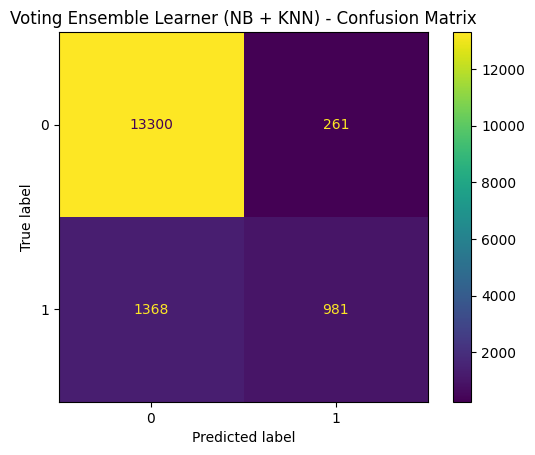

In [ ]:
# Evaluate the ensemble model
print("Classification report for Ensemble Learner (NB + KNN Soft Voting)")
print(classification_report(y_classi_test, y_ensembler_pred))

ensemble_learner_cm = confusion_matrix(y_classi_test, y_ensembler_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_learner_cm,
    display_labels=ensemble_learner.classes_
)
disp.plot()
plt.title('Voting Ensemble Learner (NB + KNN) - Confusion Matrix')
plt.show()

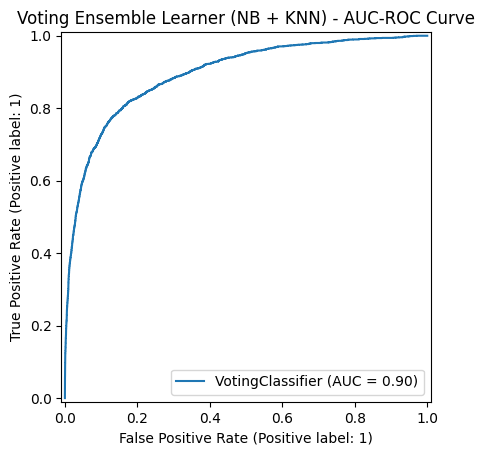

In [ ]:
ensemble_roc = RocCurveDisplay.from_estimator(ensemble_learner, x_classi_test, y_classi_test)
plt.title('Voting Ensemble Learner (NB + KNN) - AUC-ROC Curve')
plt.show()